# General Examples

A place to keep processing or other functionality that may lie outside of the standard pipeline.

In [1]:
from pathlib import Path
import os
import matplotlib.pyplot as plt
import numpy as np
import suite2p
import mbo_utilities as mbo
from copy import deepcopy
import lbm_suite2p_python as lsp
import fastplotlib as fpl
import tifffile

import lbm_suite2p_python.utils
import lbm_suite2p_python.zplane

Image(value=b'\x89PNG\r\n\x1a\n\x00\x00\x00\rIHDR\x00\x00\x01,\x00\x00\x007\x08\x06\x00\x00\x00\xb6\x1bw\x99\x…

Valid,Device,Type,Backend,Driver
✅ (default),NVIDIA RTX A4000,DiscreteGPU,Vulkan,560.94
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
✅,NVIDIA RTX A4000,DiscreteGPU,D3D12,
❗ limited,Microsoft Basic Render Driver,CPU,D3D12,
❌,NVIDIA RTX A4000/PCIe/SSE2,Unknown,OpenGL,4.6.0 NVIDIA 560.94


## Preview Scan

### [mbo_utilities.read_scan](https://millerbrainobservatory.github.io/mbo_utilities/api/core.html#mbo_utilities.read_scan) 
reads a raw [scanimage tiff](https://millerbrainobservatory.github.io/guides/lbm_data.html#lbm-metadata) lazily.

It takes a list of filesnames ["file_1", "file_2"]:
``` python
# returns a list of 'tif' files in this directory
files = mbo.get_files("D://User_Data//animal_01//", str_contains='tif')
```

Or a [glob/wildcard](https://www.malikbrowne.com/blog/a-beginners-guide-glob-patterns/)
```python
# * matches everything after _00< including the file extensions
files = r"D://User_Data//animal_01//raw_scanimage_fname_00*"
```
And returns a `scan` object that can be used like a 4D numpy array [T, Z, X, Y]

This object takes negligible memory until it is indexed `scan[:, 0, :, :] # first z-plane`

In [8]:
scan = mbo.read_scan(r"D://User_Data//animal_01//raw_scanimage_fname_00*)
scan.shape

Detected possible escaped characters in the path. Use a raw string (r'...') or double backslashes.


(5632, 14, 448, 448)

Ignore "Draw Error: Viewport has invalid rect Rect"
It is being worked on.

Data provided and set.
Is running jupyter


RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
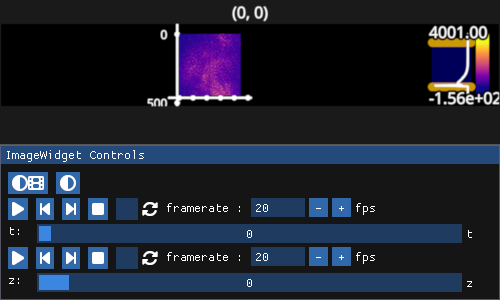

Draw error
Traceback (most recent call last):
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\rendercanvas\base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "C:\Users\RBO\repos\fastplotlib\fastplotlib\layouts\_imgui_figure.py", line 120, in _render
    self.imgui_renderer.render()
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\utils\imgui\imgui_renderer.py", line 168, in render
    render_pass.end()
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3509, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_helpers.py", line 457, in proxy_func
    raise wgpu_error
  File "C:\Users\RBO\miniforge3\envs\s3d\Lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3509, in en

In [6]:
iw = mbo.run_gui(scan)
iw.show()

In [5]:
animal_path = Path(r"D://User_Data//animal_01//raw_scanimage_fname_00*")
assembled_path = animal_path.joinpath("assembled")
save_path = animal_path.joinpath("results")
print(f"Saving raw tiffs to:        {assembled_path}")
print(f"Saving suite2p results to:  {save_path}")

Saving raw tiffs to:        D:\W2_DATA\kbarber\2025-02-27\mk301\assembled
Saving suite2p results to:  D:\W2_DATA\kbarber\2025-02-27\mk301\results


In [8]:
# you can do this too
#iw = fpl.ImageWidget(data=scan)

RFBOutputContext()

In [32]:
scan.shape

(5632, 14, 448, 448)

In [3]:
zstack = scan[50, :, :, :]
data.shape

(14, 448, 448)

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
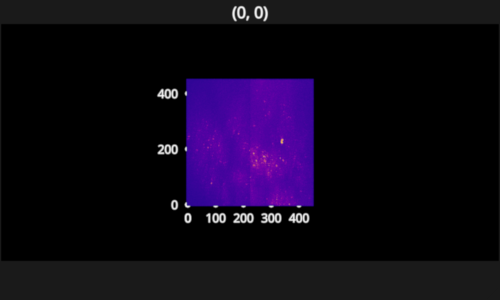

In [8]:
# coming soon
# fig = fpl.Figure(cameras="3d")
# volume = fig[0, 0].add_image_volume(data=data)
# fig.show()

In [26]:
# very easy filesystem traversal: Path(string).parent.parent.joinpath("path", "to", "file")
ops_files = mbo.get_files(Path(assembled_path).parent.joinpath("results"), "ops.npy", 4)
print([Path(x).parts[-3:] for x in ops_files[:3]])  # sorry this is ugly, to hide the root directory for the notebook output

[('plane_01_mk301', 'plane0', 'ops.npy'), ('plane_02_mk301', 'plane0', 'ops.npy'), ('plane_03_mk301', 'plane0', 'ops.npy')]


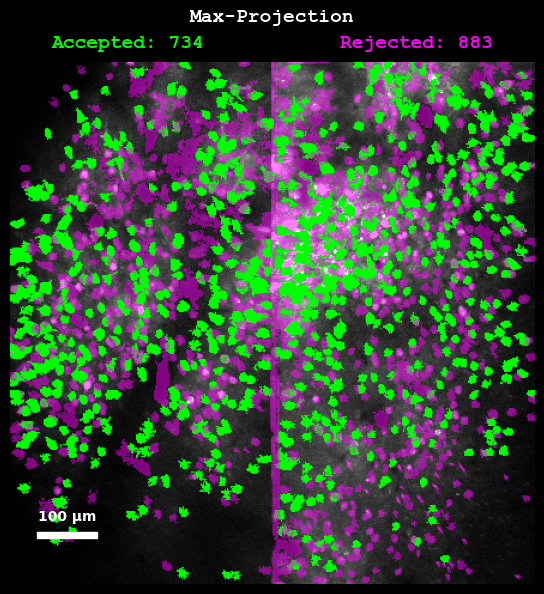

In [31]:
ops_plane_7 = lbm_suite2p_python.zplane.load_ops(ops_files[7])
lsp.plot_projection(ops_plane_7, add_scalebar=True, proj="max_proj", display_masks=True, accepted_only=False)

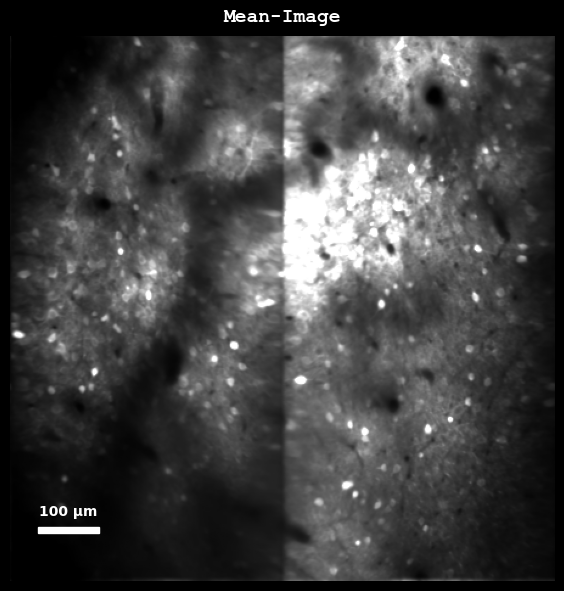

In [33]:
lsp.plot_projection(ops_plane_7, add_scalebar=True, proj="meanImg", display_masks=False)

In [ ]:
f, fneu, spks = lsp.load_traces(ops_plane_7)
spks = lbm_suite2p_python.zplane.load_planar_results(ops_plane_7)
# lsp.plot_rastermap(

## Compare multiple z-planes

In [6]:
plane_6 = tifffile.memmap(input_files[5])
plane_7 = tifffile.memmap(input_files[6])

RFBOutputContext()

JupyterRenderCanvas(css_height='300.0px', css_width='500.0px')
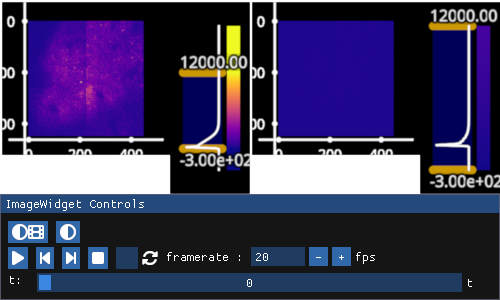

Draw error
Traceback (most recent call last):
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\_coreutils.py", line 41, in log_exception
    yield
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\rendercanvas\base.py", line 409, in _draw_frame_and_present
    self._draw_frame()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\fastplotlib\layouts\_imgui_figure.py", line 111, in _render
    self.imgui_renderer.render()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\utils\imgui\imgui_renderer.py", line 161, in render
    render_pass.end()
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_api.py", line 3289, in end
    libf.wgpuRenderPassEncoderEnd(self._internal)
  File "C:\Users\RBO\miniforge3\envs\lsp\lib\site-packages\wgpu\backends\wgpu_native\_helpers.py", line 394, in proxy_func
    raise wgpu_error  # the frame above is more interesting ↑↑
wgpu._classes.GPUValidationError: Validation Erro

In [10]:
iw = fpl.ImageWidget(data=[plane_6, plane_7])
iw.show()